# <center>**Theta Residues**<center>

**Libraries**

In [1]:
import numpy as np
import mbloodmoon.iros_management as iros
import mbloodmoon as bm
from mbloodmoon.types import CoordEquatorial

from _IROS_support import _handle_dirpaths

In [2]:
mask_FITS = "wfm_mask.fits"

skyfield = "GalacticCenter"
#data_FITS = "20241011_galctr_rxte_sax_2-30keV_1ks_2cams_sources_cxb"
#data_FITS = "20250320_galctr_rxte_sax_2-50keV_1ks_sources_cxb_infmaskdet"
#data_FITS = "20250131_galctr_rxte_sax_2-30keV_1ks_sources_cxb"
data_FITS = "20250430_galctr_rxte_sax_2-50keV_1ks_realmask_infdet_sources_cxb"
#data_FITS = "20250430_galctr_rxte_sax_2-50keV_1ks_opaquemask_realdet_sources_cxb"
#data_FITS = "20250430_galctr_rxte_sax_2-50keV_1ks_thinmask_realdet_sources_cxb"


#skyfield = "Crab"
#data_FITS = "20250227_crab_cxb_2-50keV_1ks"

#skyfield = "IROSDummy"
#data_FITS = "catalog_noCXB_1Crab_infdet_2-50keV_1ks"


N_TEST = "GalCenPeppe_x5y1_detected_240625"

UPX, UPY = 5, 1

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    test_name=N_TEST,
)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = "detected"

filepaths = bm.simulation_files(simul_data)
energy_range = (None, None)
#s0 = CoordEquatorial(ra=223.438453172364, dec=-22.0306369561417)
#s1 = CoordEquatorial(ra=231.465619039524, dec=-24.3850523670622)
#s2 = CoordEquatorial(ra=241.426574413659, dec=-26.6219960573764)
#s3 = CoordEquatorial(ra=253.284954989872, dec=-28.3032728404397)
#s4 = CoordEquatorial(ra=266.4, dec=-28.94)
#s5 = CoordEquatorial(ra=266.4, dec=-17.3775096005863)
#s6 = CoordEquatorial(ra=266.4, dec=-6.63642699386322)
#s7 = CoordEquatorial(ra=266.4, dec=2.68547284486862)
#s8 = CoordEquatorial(ra=266.4, dec=10.4607609542733)
#coords = (
#    s0, s1, s2, s3, s5, s6, s7, s8,
#)
#assert (s4 not in coords) and (len(coords) == 8)
coords = None


#from temp_camera import codedmask
from mbloodmoon.mask import codedmask

wfm = codedmask(mask_path, UPX, UPY)
sdlA = bm.simulation(filepaths[cam_a][dataset], energy_range=energy_range, coords=coords)
sdlB = bm.simulation(filepaths[cam_b][dataset], energy_range=energy_range, coords=coords)

catalogA = bm.simulation(filepaths[cam_a]["sources"])
catalogB = bm.simulation(filepaths[cam_b]["sources"])

In [3]:
mask_path, simul_data, save_path

('/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/wfm_mask.fits',
 '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/GalacticCenter/20250430_galctr_rxte_sax_2-50keV_1ks_realmask_infdet_sources_cxb/',
 '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Outputs/OutGalacticCenter/20250430_galctr_rxte_sax_2-50keV_1ks_realmask_infdet_sources_cxb/GalCenPeppe_x5y1_detected_240625/')

In [4]:
database_name = save_path + f"IROS_sources_database_TEST_{N_TEST}.fits"
database = iros.load_iros_data(database_name)

# Loading data...
# Loading completed!


In [5]:
from copy import deepcopy
from pandas import DataFrame

from mbloodmoon.io import SimulationDataLoader
from mbloodmoon.mask import CodedMaskCamera
from mbloodmoon.coords import equatorial2shift, shift2angle


def get_catalog_theta(
    data: dict,
    catalogs: tuple[np.recarray],
    sdls: tuple[SimulationDataLoader],
    camera: CodedMaskCamera,
) -> DataFrame:
    """Returns catalog sources respective camera angular coordinates."""
    db = {
        cameraID: deepcopy({
            "theta_x": [],
            "theta_y": [],
        })
        for cameraID in data.keys()
    }

    for sdl, cat, cameraID in zip(
        sdls, catalogs, data.keys(),
    ):
        print(f"# Checking {cameraID.upper()}...")
        for name in data[cameraID]["catalog_name"]["data"]:
            cat_ra = cat.data[cat.data["NAME"] == name]["RA"][0]
            cat_dec = cat.data[cat.data["NAME"] == name]["DEC"][0]
            sx, sy = equatorial2shift(sdl, camera, cat_ra, cat_dec)
            db[cameraID]["theta_x"].append(shift2angle(camera, sx))
            db[cameraID]["theta_y"].append(shift2angle(camera, sy))

    return iros.dict2df(db)



catalog_theta = get_catalog_theta(database, (catalogA, catalogB), (sdlA, sdlB), wfm)

# Checking CAM1A...
# Checking CAM1B...


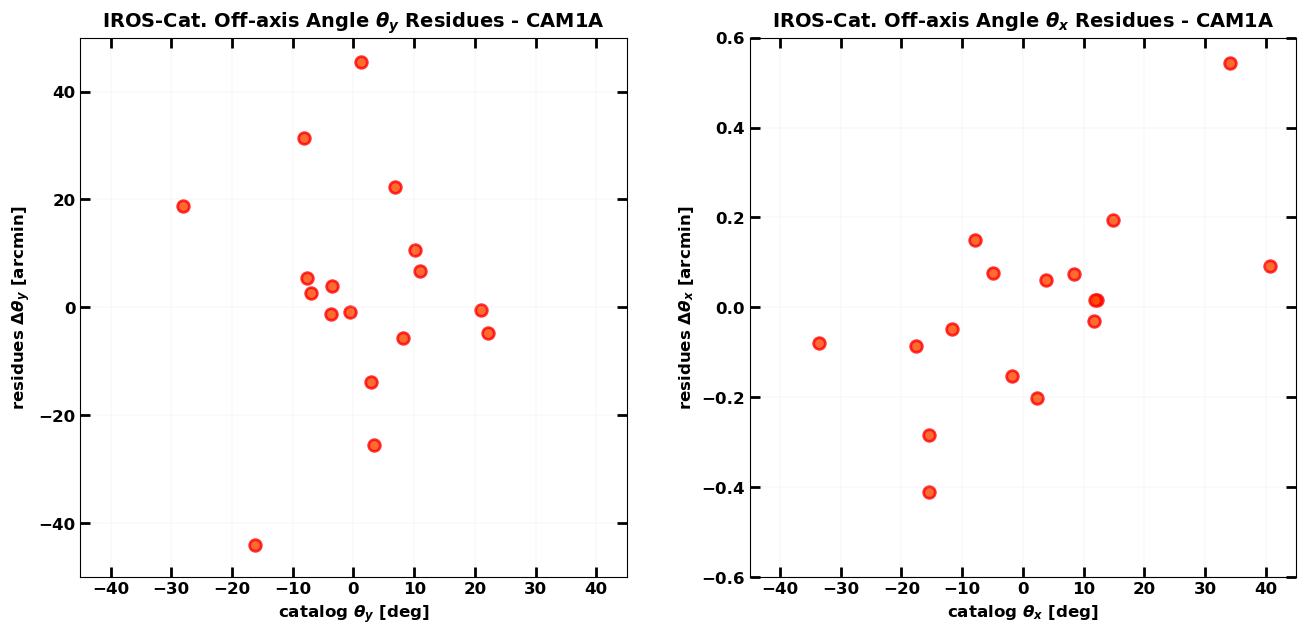

In [6]:
# CAM1A
thetay_cam1a = database[cam_a]["theta_y"]["data"]
thetax_cam1a = database[cam_a]["theta_x"]["data"]

thetay_catalog_cam1a = catalog_theta[cam_a]["theta_y"]
thetax_catalog_cam1a = catalog_theta[cam_a]["theta_x"]

iros.plot_sequence(
    input_sequence=[60 * (thetay_cam1a - thetay_catalog_cam1a), 60 * (thetax_cam1a - thetax_catalog_cam1a)],
    title=[r"IROS-Cat. Off-axis Angle $\theta_{y}$ Residues - CAM1A", r"IROS-Cat. Off-axis Angle $\theta_{x}$ Residues - CAM1A"],
    x=[thetay_catalog_cam1a, thetax_catalog_cam1a],
    xlabel=[r"catalog $\theta_{y}$" + " [deg]", r"catalog $\theta_{x}$" + " [deg]"],
    ylabel=[r"residues $\Delta\theta_{y}$" + " [arcmin]", r"residues $\Delta\theta_{x}$" + " [arcmin]"],
    style=["scatter"]*2,
    offsetx=[(-45, 45)]*2,
    offsety=[(-50, 50), (-0.6, 0.6)],
)

# Loading data...
# Loading completed!


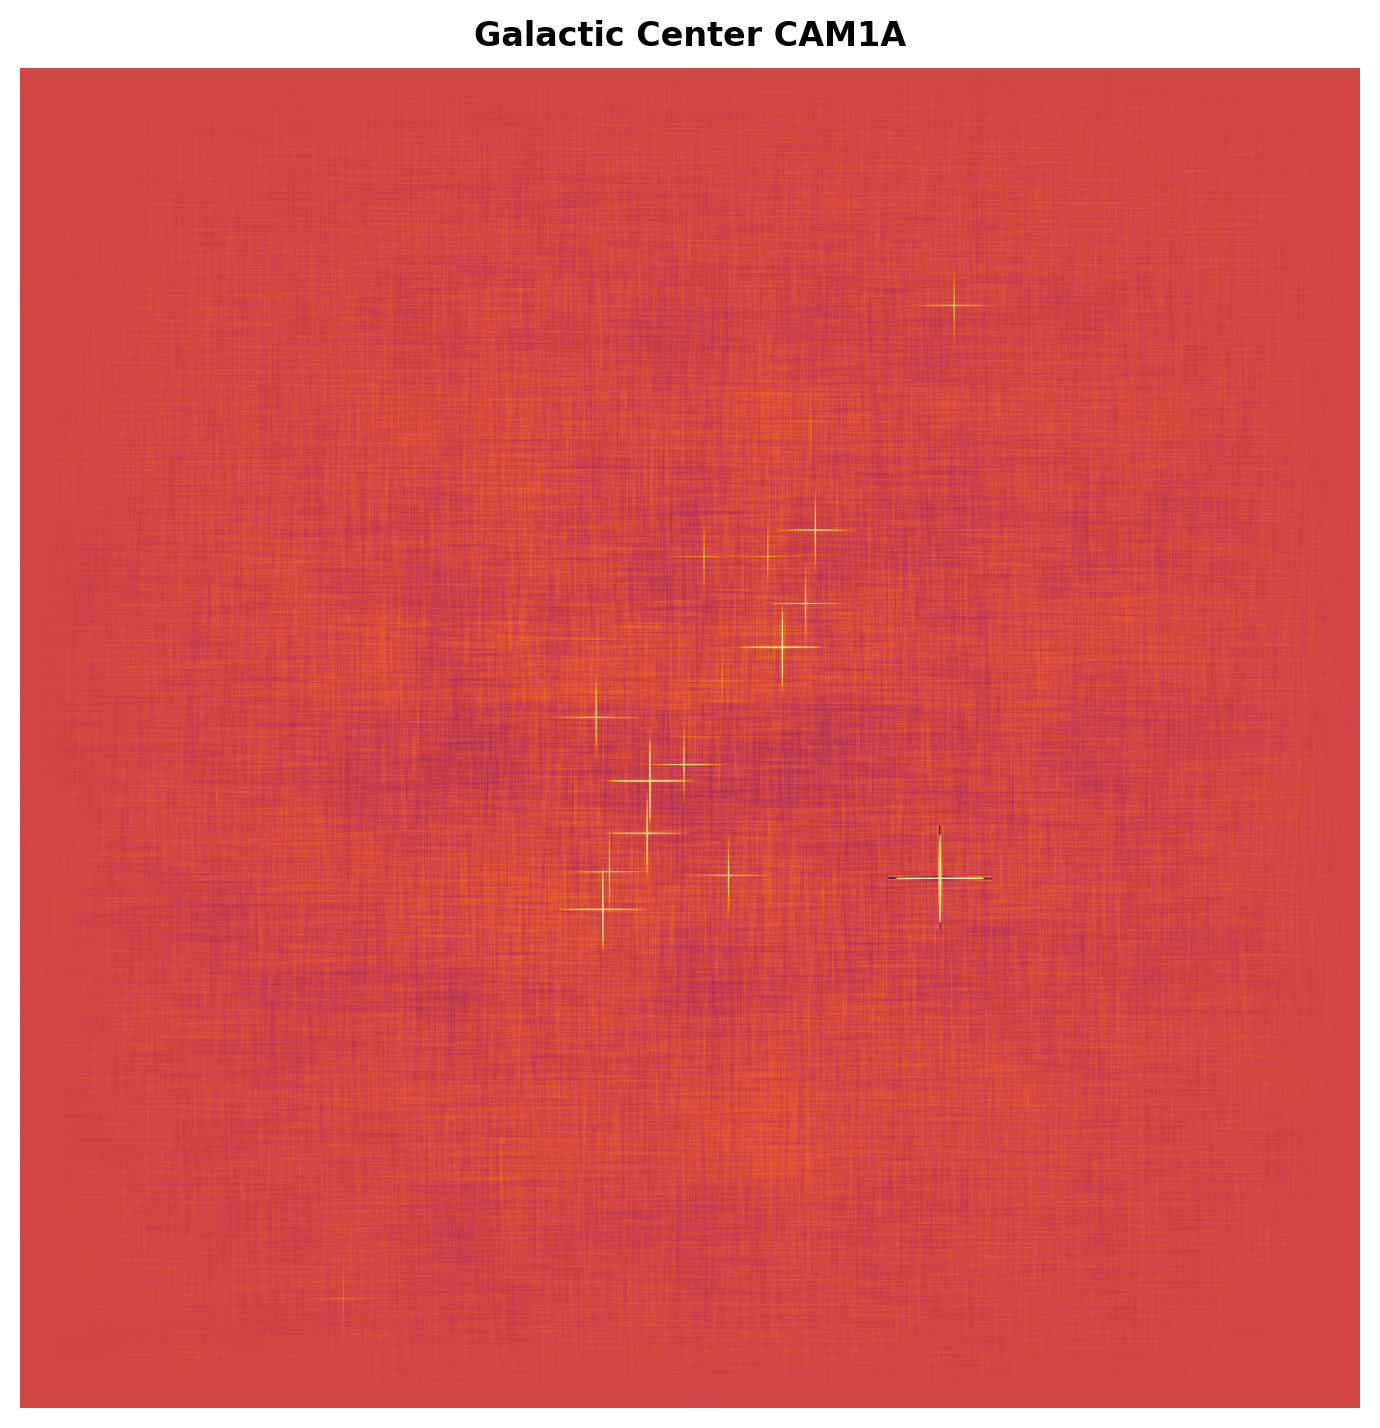

In [11]:
filepath = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Outputs/OutGalacticCenter/20250430_galctr_rxte_sax_2-50keV_1ks_realmask_infdet_sources_cxb/GalCenPeppe_x5y1_detected_240625/"
comp_iros_sky, _ = iros.load_sky(filepath + "COMPOSED_OUTsky_IROS_CAM1A_CAM1B_TEST_GalCenPeppe_x5y1_detected_240625.fits")

def map_sources(db, sky, camera) -> tuple[list[str], list[tuple[int, int]]]:
    """Makes sources ID and pos in the sky."""
    n, m = sky.shape
    p, q = camera.shape_sky

    fy, fx = p // n, q // m

    sources_ID, sources_pos = [], []
    for s, y, x in zip(
        db["cam1a"]["catalog_name"]["data"],
        db["cam1a"]["y"]["data"],
        db["cam1a"]["x"]["data"],
    ):
        sources_ID.append(s)
        sources_pos.append((y * fy, x * fx))
    return sources_ID, sources_pos


sources_ID, sources_pos = map_sources(database, comp_iros_sky, wfm)
iros.plot_sky(
    sky=comp_iros_sky,
    title="Galactic Center CAM1A",
)

In [8]:
assert False

AssertionError: 

In [ ]:
## CAM1B
#thetay_cam1b = database[cam_b]["theta_y"]["data"]
#thetax_cam1b = database[cam_b]["theta_x"]["data"]
#
#thetay_catalog_cam1b = catalog_theta[cam_b]["theta_y"]
#thetax_catalog_cam1b = catalog_theta[cam_b]["theta_x"]
#
#iros.plot_sequence(
#    input_sequence=[60 * (thetay_cam1b - thetay_catalog_cam1b), 60 * (thetax_cam1b - thetax_catalog_cam1b)],
#    title=[r"IROS-Cat. Off-axis Angle $\theta_{y}$ Residues - CAM1B", r"IROS-Cat. Off-axis Angle $\theta_{x}$ Residues - CAM1B"],
#    x=[thetay_catalog_cam1b, thetax_catalog_cam1b],
#    xlabel=[r"catalog $\theta_{y}$" + " [deg]", r"catalog $\theta_{x}$" + " [deg]"],
#    ylabel=[r"residues $\Delta\theta_{y}$" + " [arcmin]", r"residues $\Delta\theta_{x}$" + " [arcmin]"],
#    style=["scatter"]*2,
#    offsetx=[(-45, 45)]*2,
#    offsety=[(-22, 22), (-2, 2)],
#)

In [ ]:
res_sky_camA, _ = iros.load_sky(save_path + f"skyRES_IROS_CAM1A_TEST_{N_TEST}.fits")
res_sky_camB, _ = iros.load_sky(save_path + f"skyRES_IROS_CAM1B_TEST_{N_TEST}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


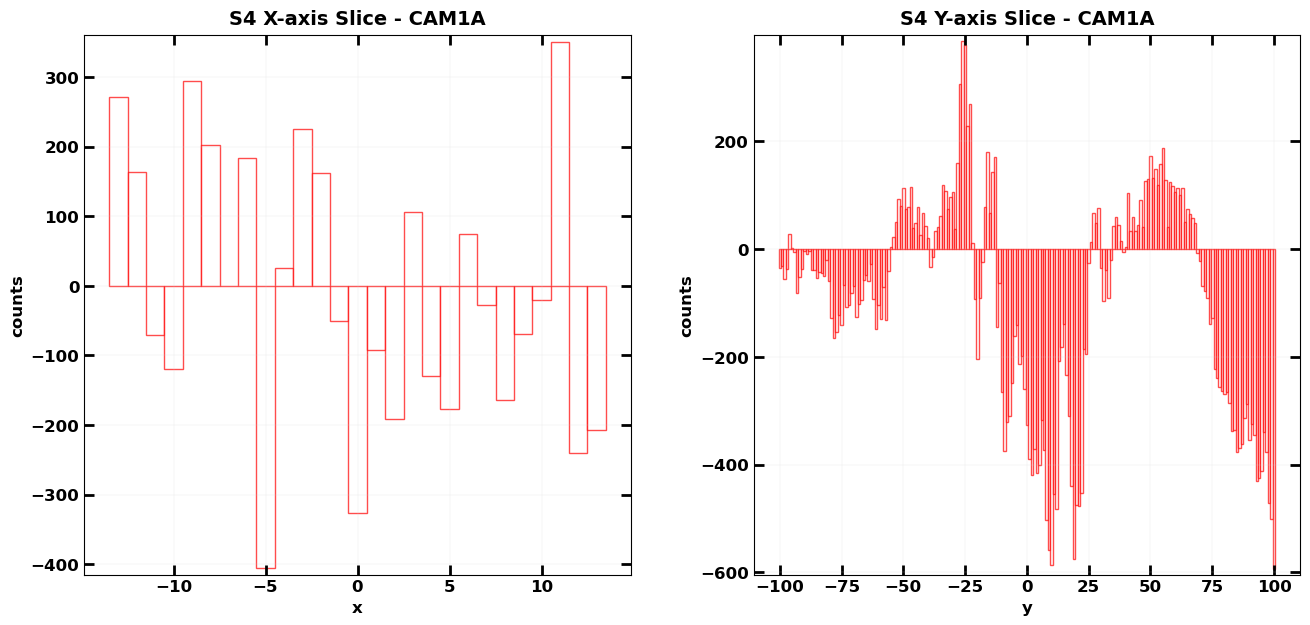

In [ ]:
# CAM1A
_to = -0

for source, y, x in zip(
    database[cam_a]["catalog_name"]["data"][:],
    database[cam_a]["y"]["data"][:],
    database[cam_a]["x"]["data"][:],
):
    iros.enhance_slices(
        sky=res_sky_camA,
        pos=(y, x),
        crp=(int(50 * (1 + UPY)), int(10 * (1 + UPX / 3))),
        source=source,
        cameraID=cam_a,
    )

In [ ]:
## CAM1B
#_to = 1
#
#for source, y, x in zip(
#    database[cam_b]["catalog_name"]["data"][:],
#    database[cam_b]["y"]["data"][:],
#    database[cam_b]["x"]["data"][:],
#):
#    iros.enhance_slices(
#        sky=res_sky_camB,
#        pos=(y, x),
#        crp=(int(50 * (1 + UPY)), int(10 * (1 + UPX / 3))),
#        source=source,
#        cameraID=cam_b,
#    )

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import mbloodmoon as bm
from mbloodmoon.types import CoordEquatorial
from mbloodmoon.mask import count, decode, variance, snratio
from mbloodmoon.mask import codedmask
from mbloodmoon.mask import argmax
import mbloodmoon.iros_management as iros

from _IROS_support import _handle_dirpaths

mask_FITS = "wfm_mask.fits"
skyfield = "IROSDummy"
data_FITS = "obliquedistr_infdet_2-50keV_1ks"

UPX, UPY = 5, 5

cam_a = "cam1a"
cam_b = "cam1b"
dataset = "detected"

mask_path = f"/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/{mask_FITS}"
simul_data = f"/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/{skyfield}/{data_FITS}"

filepaths = bm.simulation_files(simul_data)
energy_range = (2, 50)
coords = None


coords = (
    CoordEquatorial(ra=249.459, dec=-67.52572),
    CoordEquatorial(ra=255.6928, dec=-60.21748),
    CoordEquatorial(ra=260.2596, dec=-51.18224),
    CoordEquatorial(ra=263.7089, dec=-40.5835),
    CoordEquatorial(ra=268.5208, dec=-17.36688),
    CoordEquatorial(ra=270.254, dec=-6.622541),
    CoordEquatorial(ra=271.6881, dec=2.672805),
    CoordEquatorial(ra=272.8929, dec=10.39376),
)
coords = None

wfm = codedmask(mask_path, UPX, UPY)
sdlA = bm.simulation(filepaths[cam_a][dataset], energy_range=energy_range, coords=coords)
sdlB = bm.simulation(filepaths[cam_b][dataset], energy_range=energy_range, coords=coords)

catalogA = bm.simulation(filepaths[cam_a]["sources"])
catalogB = bm.simulation(filepaths[cam_b]["sources"])

detectors = tuple(count(wfm, sdl.data)[0] for sdl in (sdlA, sdlB))
skies = tuple(decode(wfm, d) for d in detectors)
variances = tuple(variance(wfm, d) for d in detectors)
snrs = tuple(snratio(sky, np.clip(var_, a_min=1, a_max=None)) for sky, var_ in zip(skies, variances))

KeyboardInterrupt: 

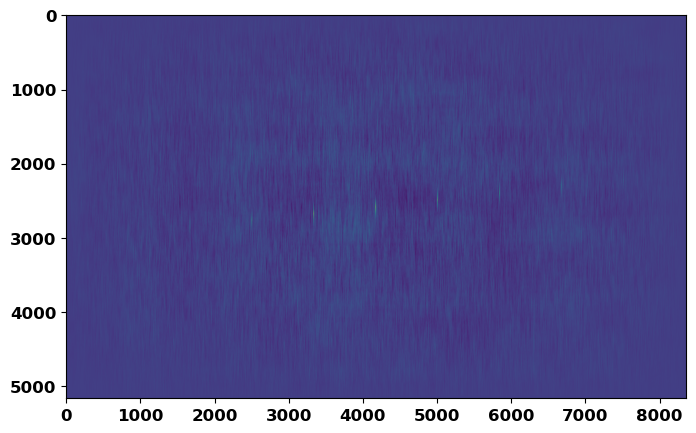

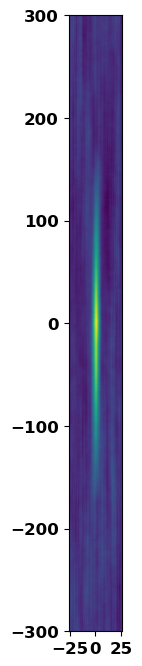

ValueError: x and y must have same first dimension, but have shapes (600,) and (601,)

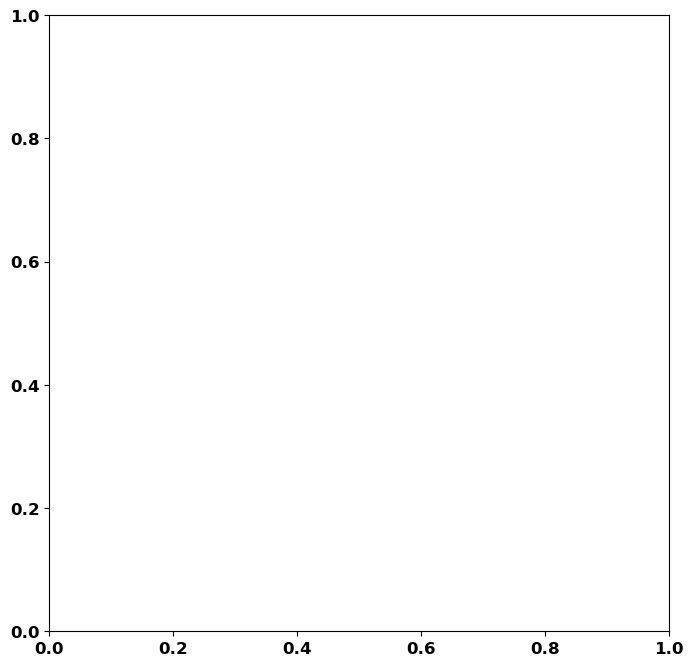

In [ ]:
upx, upy = wfm.upscale_f

plt.figure(figsize=(8, 8))
plt.imshow(skies[0])
plt.show()

crpx, crpy = int(10 * (1 + upx / 3)), int(50 * (1 + upy))
s = iros.crop(skies[0], argmax(skies[0]), (crpy, crpx))
sign = iros.crop(snrs[0], argmax(snrs[0]), (crpy, crpx))

plt.figure(figsize=(8, 8))
plt.imshow(
    X=s,
    extent=(-crpx, crpx, -crpy, crpy),
)
plt.show()

plt.figure(figsize=(8, 8))
plt.plot(np.arange(-crpy, crpy), s[:, argmax(s)[1]])
plt.plot((0, 0), (7000, -1000), color='r', linestyle='dashdot', linewidth=0.75, alpha=0.3)
plt.title("TRUE SOURCE: slice y - axis")
plt.show()

plt.figure(figsize=(8, 8))
plt.plot(np.arange(-crpx, crpx), s[argmax(s)[0], :])
plt.plot((0, 0), (7000, -1000), color='r', linestyle='dashdot', linewidth=0.75, alpha=0.3)
plt.title("TRUE SOURCE: slice x - axis")
plt.show()

print(argmax(s), s.max())
print(argmax(sign), sign.max())